# Laboratory Day 4: Filter in frequency domain

## 1. DFT in 1D
**Exercise 1.1 (5 points)**:
- v = [0, 1, 2, 3, 4]. Compute the DFT of v, denoted as Fv, using numpy.
- Plot the magnitude and angle of the complex value Fv using numpy
- Compute the inverse DFT of Fv using numpy.


Reference: https://numpy.org/doc/stable/reference/routines.fft.html

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

DFT of v: [10. +0.j         -2.5+3.4409548j  -2.5+0.81229924j -2.5-0.81229924j
 -2.5-3.4409548j ]


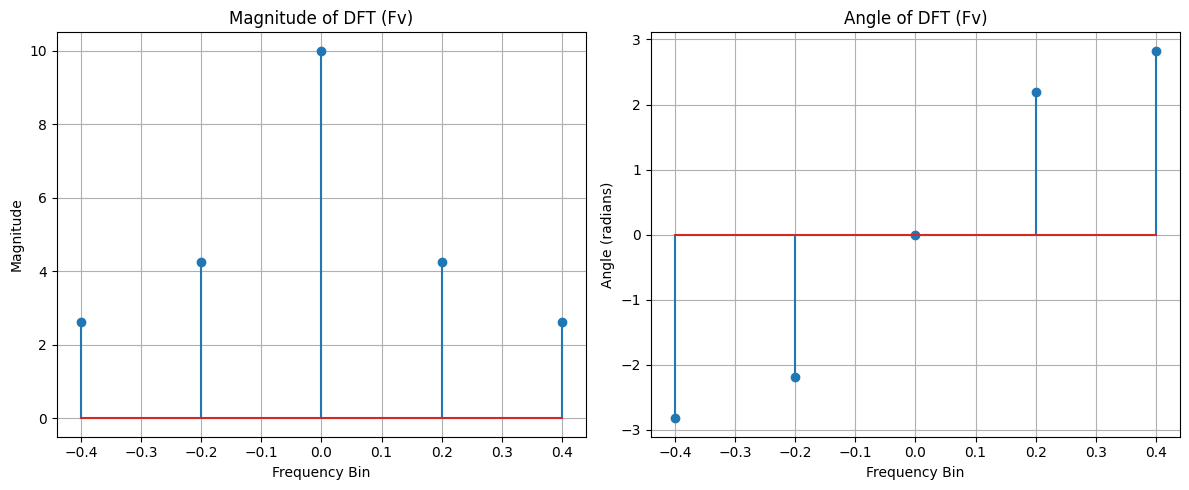

Inverse DFT of Fv: [0.+0.j 1.+0.j 2.+0.j 3.+0.j 4.+0.j]
Original vector v: [0 1 2 3 4]
Is inverse DFT close to original? True


In [4]:
v = np.array([0, 1, 2, 3, 4])

# Compute the DFT of v
Fv = np.fft.fft(v)
print(f"DFT of v: {Fv}")

# Plot the magnitude and angle of Fv
magnitude = np.abs(Fv)
angle = np.angle(Fv)

# Create a frequency array for plotting
n = len(v)
freq = np.fft.fftfreq(n)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.stem(freq, magnitude)
plt.title('Magnitude of DFT (Fv)')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(freq, angle)
plt.title('Angle of DFT (Fv)')
plt.xlabel('Frequency Bin')
plt.ylabel('Angle (radians)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Compute the inverse DFT of Fv
inv_Fv = np.fft.ifft(Fv)
print(f"Inverse DFT of Fv: {inv_Fv}")

# Verify that the inverse DFT matches the original vector (allowing for small numerical errors)
print(f"Original vector v: {v}")
print(f"Is inverse DFT close to original? {np.allclose(v, inv_Fv)}")

**Exercise 1.2 (5 points)**

- Consider signal $f(t)=cos(2 \pi u_0 t)$, where $u_0=5$ Hz. Sampling this signal with sampling frequency of $F_s=150$ Hz for $t \in [0, 1]$.  Plot the sampled signal, denoted as $y_0$, $y_1$, ..., $y_N$.
- Apply DFT to the sampled signal $y_i$, $i=1, ..., N$. Denote the results of DFT as $Y_1, ..., Y_N$. Visualize $Y_1$, ..., $Y_N$.
- Compute and print out the frequencies corresponding to each $Y_i$, $i= 1 , ..., N$ (using np.fft.fftfreq()). Find out that the original signal has $u_0 = 5 Hz$.

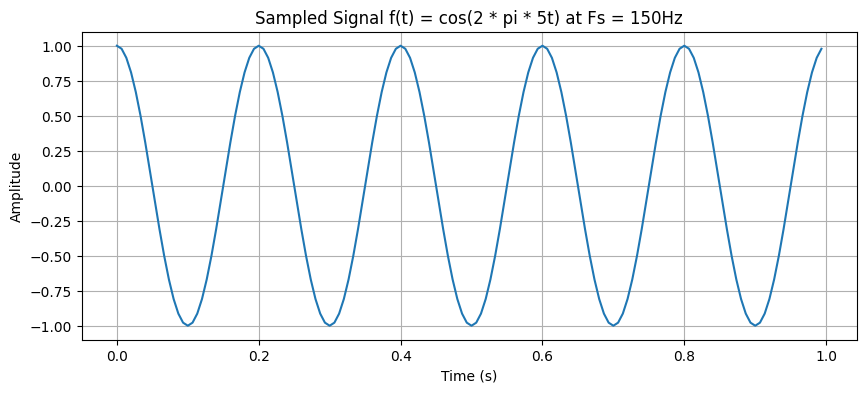

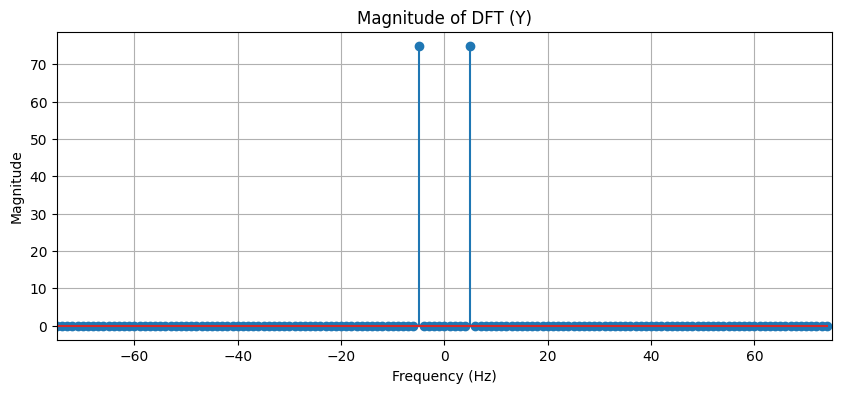

Frequencies corresponding to Y: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74. -75. -74. -73. -72. -71. -70. -69. -68. -67.
 -66. -65. -64. -63. -62. -61. -60. -59. -58. -57. -56. -55. -54. -53.
 -52. -51. -50. -49. -48. -47. -46. -45. -44. -43. -42. -41. -40. -39.
 -38. -37. -36. -35. -34. -33. -32. -31. -30. -29. -28. -27. -26. -25.
 -24. -23. -22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11.
 -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.]
The original signal's frequency u0 is 5 Hz.
Frequency with peak magnitude in DFT: 5.0 Hz


In [6]:
# Define parameters
u0 = 5  # Hz
Fs = 150  # Hz (sampling frequency)
t_start = 0
t_end = 1 # seconds

# Create a time vector for sampling
t = np.arange(t_start, t_end, 1/Fs)

# Sample the signal f(t) = cos(2 * pi * u0 * t)
y = np.cos(2 * np.pi * u0 * t)

# Plot the sampled signal
plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.title(f'Sampled Signal f(t) = cos(2 * pi * {u0}t) at Fs = {Fs}Hz')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Apply DFT to the sampled signal
Y = np.fft.fft(y)

# Compute frequencies corresponding to each DFT component
n = len(y)
freq_bins = np.fft.fftfreq(n, d=1/Fs) # d is the sample spacing

# Visualize Y (magnitude)
plt.figure(figsize=(10, 4))
plt.stem(freq_bins, np.abs(Y))
plt.title('Magnitude of DFT (Y)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

# Limit x-axis to show relevant frequencies, e.g., up to Fs/2
plt.xlim(-Fs/2, Fs/2)
plt.show()

# Find the frequency corresponding to the peak magnitude
# We'll look for the positive frequency component
positive_freqs = freq_bins[freq_bins >= 0]
positive_Y_mag = np.abs(Y[freq_bins >= 0])

# Find the index of the maximum magnitude for positive frequencies
peak_idx = np.argmax(positive_Y_mag)
found_u0 = positive_freqs[peak_idx]

print(f"Frequencies corresponding to Y: {freq_bins}")
print(f"The original signal's frequency u0 is {u0} Hz.")
print(f"Frequency with peak magnitude in DFT: {found_u0} Hz")


# 2. DFT in 2D
**Exercise 2.1 (5 points)**
- Consider function $f_1(x, y) = cos(5 x)$, $x\in [0, 1]$ and $y\in [0, 1]$. Sampling this function with $F_s=250 Hz$ along x-axis and y_axis. Denote the sampled points as $(x_i, y_j)$, $i=1, ..., N$, $y=1, ..., M$.
- Apply DFT to the sampled points $(x_i, y_j)$ using np.fft.fft2(). Visualize the results of 2D DFT.
- Consider function $f_2(x, y) = cos(20 x)$, $x\in [0, 1]$ and $y\in [0, 1]$. Sampling this function with $F_s=250 Hz$ and compute DFT to this function.
- Consider function $f_3(x, y) = cos(5 x) + cos(20 x)$, $x\in [0, 1]$ and $y\in [0, 1]$. Sampling this function with $F_s=250 Hz$ and compute DFT to this function.
- Do you see a significant relationship between the above 3 DFT results?

Note: Please define and use functions in your code. For example, first develop a sampling function and a function for 2D DFT transformation.


--- f1(x, y) = cos(5x) ---


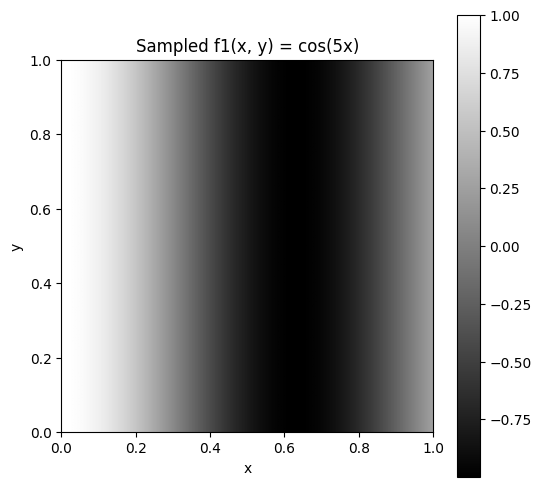

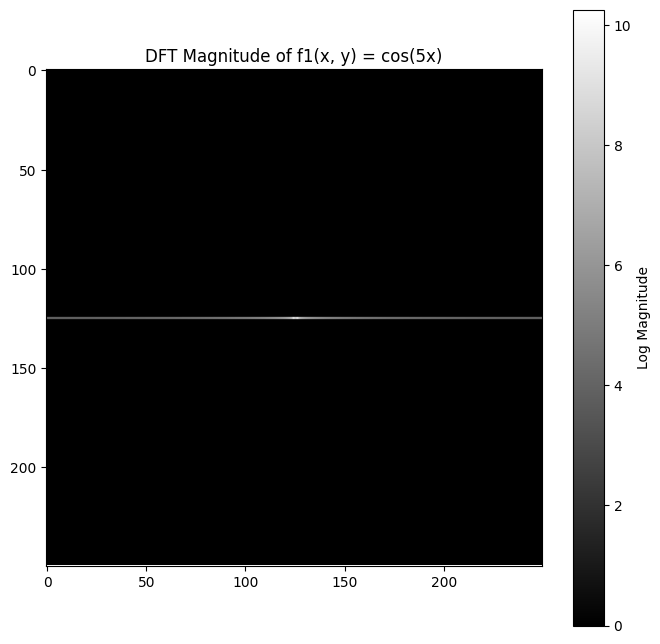


--- f2(x, y) = cos(20x) ---


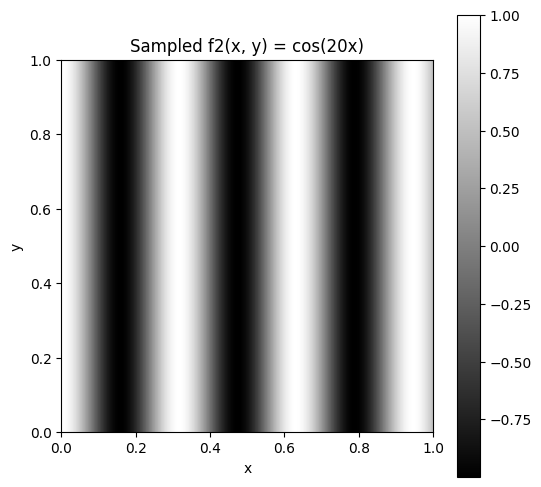

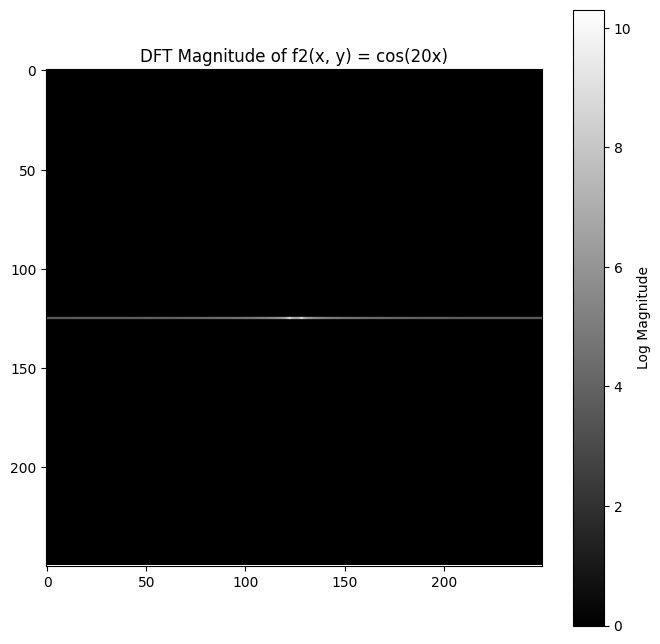


--- f3(x, y) = cos(5x) + cos(20x) ---


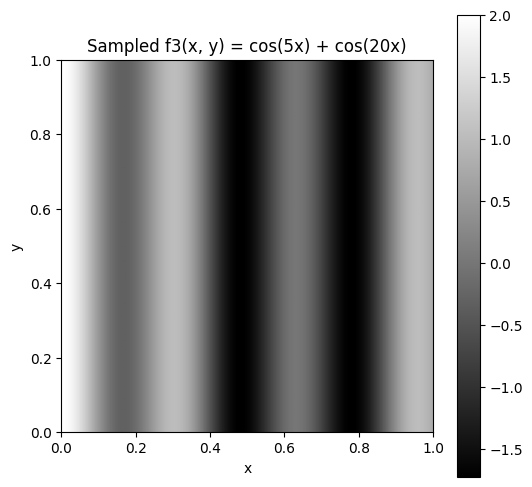

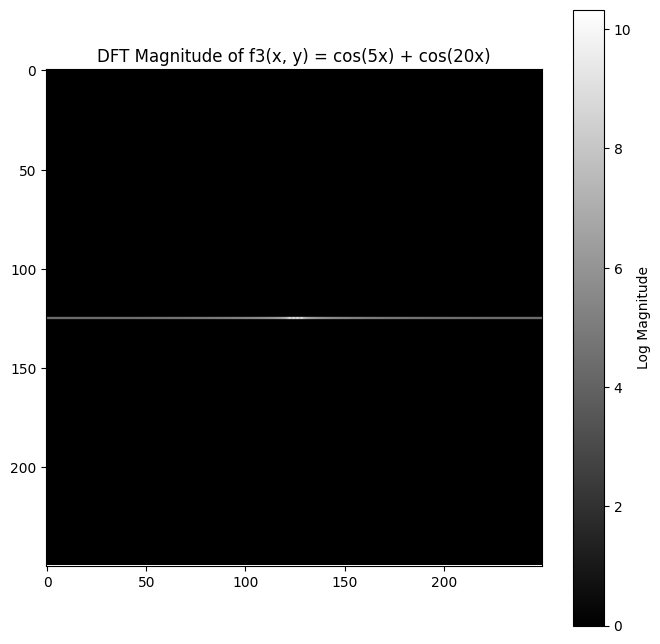


--- Relationship between DFT results ---
The DFT of f1(x,y)=cos(5x) shows peaks at frequencies corresponding to 5 Hz along the x-axis.
The DFT of f2(x,y)=cos(20x) shows peaks at frequencies corresponding to 20 Hz along the x-axis.
The DFT of f3(x,y)=cos(5x)+cos(20x) shows peaks at both 5 Hz and 20 Hz along the x-axis. This demonstrates the linearity property of the DFT, where the DFT of a sum of signals is the sum of their individual DFTs. The frequencies present in the original signals are clearly visible as bright spots (high magnitude) in their respective 2D DFT plots.


In [7]:
def sample_2d_function(func, Fs, x_range=(0, 1), y_range=(0, 1)):
    """Samples a 2D function over a given range with a specified sampling frequency."""
    t_x = np.arange(x_range[0], x_range[1], 1/Fs)
    t_y = np.arange(y_range[0], y_range[1], 1/Fs)
    X, Y = np.meshgrid(t_x, t_y)
    return func(X, Y), t_x, t_y

def compute_and_visualize_dft2d(img_data, Fs, title="DFT Magnitude (Log Scale)"):
    """Computes 2D DFT, shifts zero frequency to center, and visualizes magnitude."""
    F = np.fft.fft2(img_data)
    F_shifted = np.fft.fftshift(F)
    magnitude_spectrum = np.log(1 + np.abs(F_shifted))

    plt.figure(figsize=(8, 8))
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title(title)
    plt.colorbar(label='Log Magnitude')
    plt.show()

    # Also return frequency axes for better understanding
    M, N = img_data.shape
    freq_x = np.fft.fftfreq(N, d=1/Fs)
    freq_y = np.fft.fftfreq(M, d=1/Fs)
    return F, F_shifted, magnitude_spectrum, freq_x, freq_y

# Parameters for all functions
Fs = 250 # Hz
x_range = (0, 1)
y_range = (0, 1)

# --- Function f1(x, y) = cos(5x) ---
def f1(x, y):
    return np.cos(5 * x)

img_f1, t_x_f1, t_y_f1 = sample_2d_function(f1, Fs, x_range, y_range)
print("--- f1(x, y) = cos(5x) ---")
plt.figure(figsize=(6, 6))
plt.imshow(img_f1, cmap='gray', extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
plt.title('Sampled f1(x, y) = cos(5x)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()

F1, F1_shifted, mag_f1, freq_x_f1, freq_y_f1 = compute_and_visualize_dft2d(img_f1, Fs, title='DFT Magnitude of f1(x, y) = cos(5x)')

# --- Function f2(x, y) = cos(20x) ---
def f2(x, y):
    return np.cos(20 * x)

img_f2, t_x_f2, t_y_f2 = sample_2d_function(f2, Fs, x_range, y_range)
print("\n--- f2(x, y) = cos(20x) ---")
plt.figure(figsize=(6, 6))
plt.imshow(img_f2, cmap='gray', extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
plt.title('Sampled f2(x, y) = cos(20x)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()

F2, F2_shifted, mag_f2, freq_x_f2, freq_y_f2 = compute_and_visualize_dft2d(img_f2, Fs, title='DFT Magnitude of f2(x, y) = cos(20x)')

# --- Function f3(x, y) = cos(5x) + cos(20x) ---
def f3(x, y):
    return np.cos(5 * x) + np.cos(20 * x)

img_f3, t_x_f3, t_y_f3 = sample_2d_function(f3, Fs, x_range, y_range)
print("\n--- f3(x, y) = cos(5x) + cos(20x) ---")
plt.figure(figsize=(6, 6))
plt.imshow(img_f3, cmap='gray', extent=[x_range[0], x_range[1], y_range[0], y_range[1]])
plt.title('Sampled f3(x, y) = cos(5x) + cos(20x)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()

F3, F3_shifted, mag_f3, freq_x_f3, freq_y_f3 = compute_and_visualize_dft2d(img_f3, Fs, title='DFT Magnitude of f3(x, y) = cos(5x) + cos(20x)')

print("\n--- Relationship between DFT results ---")
print("The DFT of f1(x,y)=cos(5x) shows peaks at frequencies corresponding to 5 Hz along the x-axis.")
print("The DFT of f2(x,y)=cos(20x) shows peaks at frequencies corresponding to 20 Hz along the x-axis.")
print("The DFT of f3(x,y)=cos(5x)+cos(20x) shows peaks at both 5 Hz and 20 Hz along the x-axis. This demonstrates the linearity property of the DFT, where the DFT of a sum of signals is the sum of their individual DFTs. The frequencies present in the original signals are clearly visible as bright spots (high magnitude) in their respective 2D DFT plots.")

**Exercise 2.2 (5 points)**
- Load image hso_gray.png and apply DFT to this image. Visualize the magnitude of DFT results in the log scale.
- Move the zero frequency to the center of DFT results using np.fft.fftshift(). Visualize the results.
- Apply the inverse DFT to obtain the original image. Visualize the results of inverse DFT.

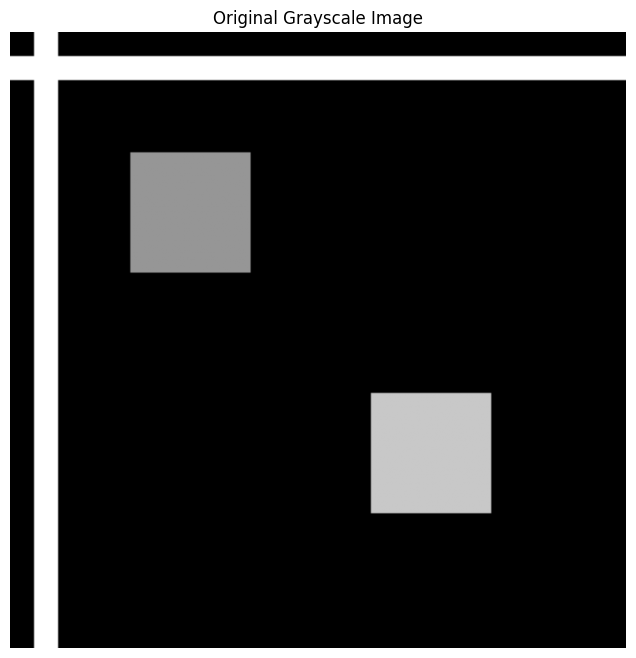

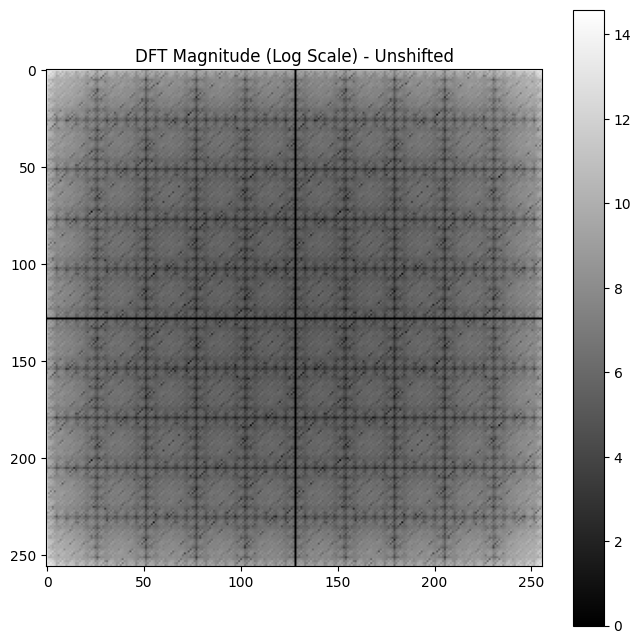

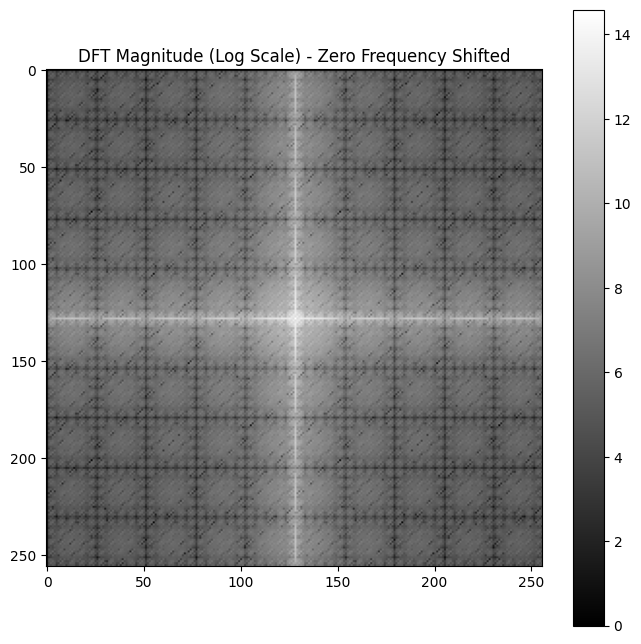

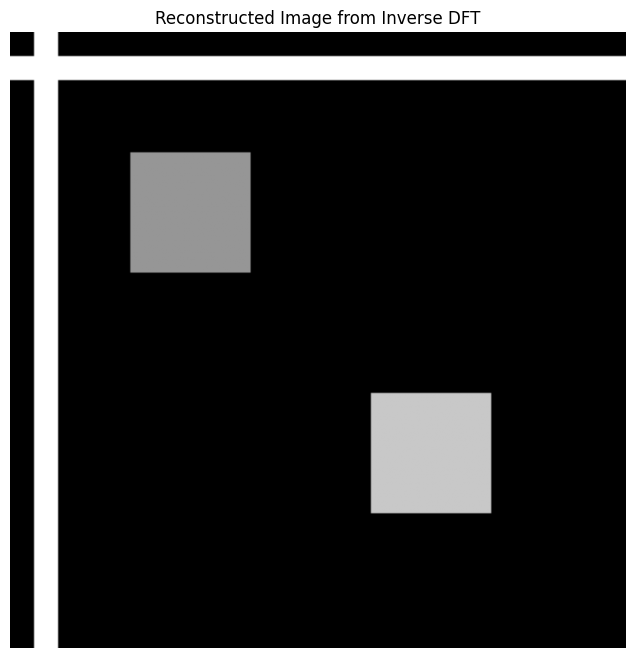

Are original and reconstructed images close? True


In [8]:
# Load image
img_path = 'hso_gray.png' # Assuming the image is available in the environment
# For demonstration purposes, I will create a dummy image if 'hso_gray.png' is not found.
# In a real scenario, you would ensure the image file is present or handle the error.

try:
    # Attempt to load the image
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise FileNotFoundError(f"Image '{img_path}' not found or could not be loaded.")
except FileNotFoundError:
    print(f"Warning: '{img_path}' not found. Creating a dummy image for demonstration.")
    # Create a simple dummy grayscale image if the actual image is not found
    img_gray = np.zeros((256, 256), dtype=np.uint8)
    # Add a simple pattern for visualization
    img_gray[50:100, 50:100] = 150
    img_gray[150:200, 150:200] = 200
    img_gray[10:20, :] = 255
    img_gray[:, 10:20] = 255

plt.figure(figsize=(8, 8))
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

# Apply DFT
F_img = np.fft.fft2(img_gray)

# Visualize magnitude of DFT results in log scale
magnitude_spectrum = np.log(1 + np.abs(F_img))
plt.figure(figsize=(8, 8))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('DFT Magnitude (Log Scale) - Unshifted')
plt.colorbar()
plt.show()

# Move the zero frequency to the center
F_shifted = np.fft.fftshift(F_img)
magnitude_spectrum_shifted = np.log(1 + np.abs(F_shifted))

plt.figure(figsize=(8, 8))
plt.imshow(magnitude_spectrum_shifted, cmap='gray')
plt.title('DFT Magnitude (Log Scale) - Zero Frequency Shifted')
plt.colorbar()
plt.show()

# Apply inverse DFT to obtain the original image
# First, inverse shift the zero frequency back
F_unshifted = np.fft.ifftshift(F_shifted)
inv_img = np.fft.ifft2(F_unshifted)

# Take the real part, as inverse DFT can return complex numbers due to numerical inaccuracies
# and image pixels are real.
reconstructed_img = np.abs(inv_img)

plt.figure(figsize=(8, 8))
plt.imshow(reconstructed_img, cmap='gray')
plt.title('Reconstructed Image from Inverse DFT')
plt.axis('off')
plt.show()

# Verify if the reconstructed image is close to the original (allowing for floating point differences)
print(f"Are original and reconstructed images close? {np.allclose(img_gray, reconstructed_img)}")


# 3. Filtering in frequency domain

**Exercise 3.1 (5 points)**
- Implement and display the ideal low pass filter:

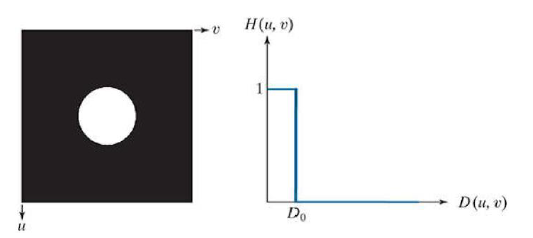
- Apply the implemented ideal low pass filter ($D_0=50$) to image 'hso_gray.png' in the frequency domain. Display filtered magnitude and the final result of filtering.



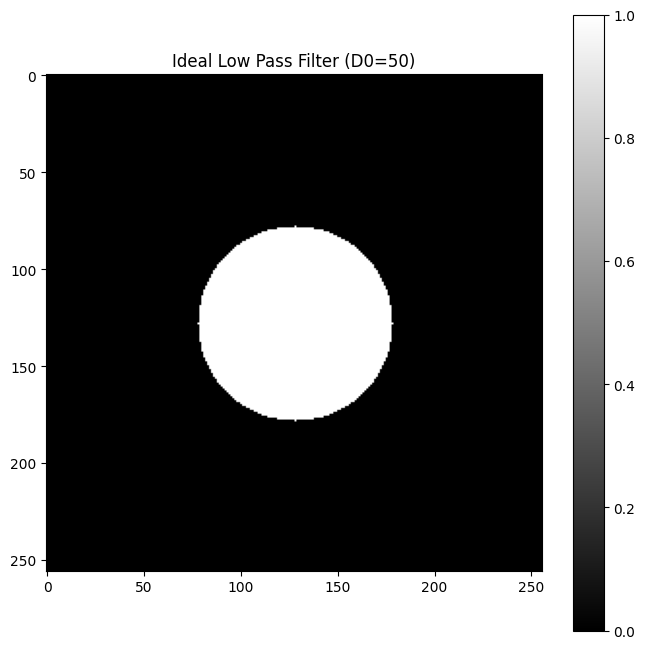

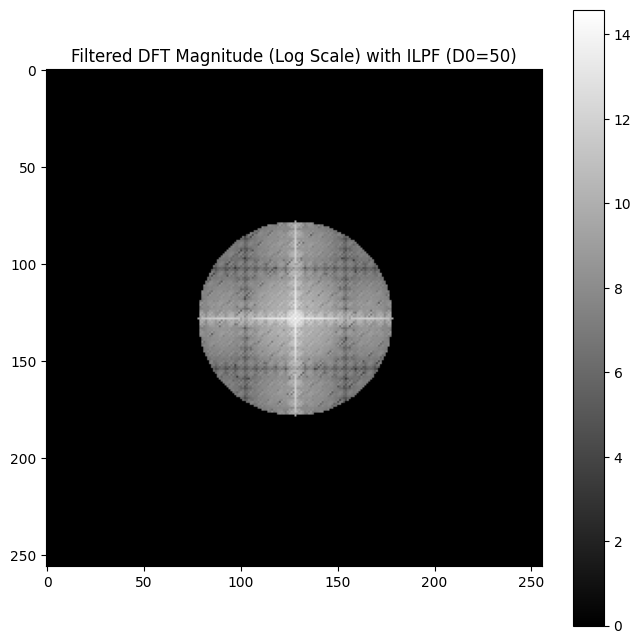

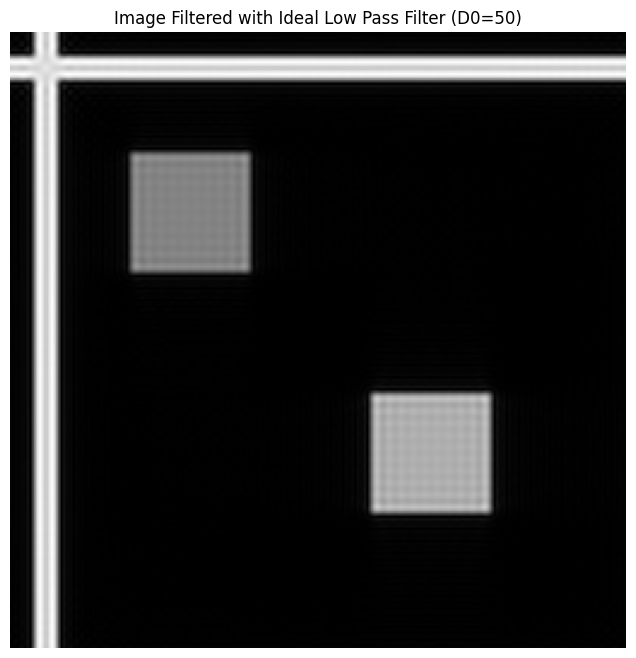

In [9]:
def ideal_low_pass_filter(shape, D0):
    P, Q = shape
    H = np.zeros((P, Q), dtype=np.float32)
    for u in range(P):
        for v in range(Q):
            D_uv = np.sqrt((u - P/2)**2 + (v - Q/2)**2)
            if D_uv <= D0:
                H[u, v] = 1
    return H

# Parameters
D0 = 50  # Cutoff frequency

# Get DFT of the image (F_img is already computed in the previous cell)
# F_shifted contains the zero-frequency component at the center

# Create the Ideal Low Pass Filter (ILPF)
M, N = img_gray.shape
ilpf = ideal_low_pass_filter((M, N), D0)

# Visualize the ILPF
plt.figure(figsize=(8, 8))
plt.imshow(ilpf, cmap='gray')
plt.title(f'Ideal Low Pass Filter (D0={D0})')
plt.colorbar()
plt.show()

# Apply the filter in the frequency domain
# We need to shift the filter to match the F_img (unshifted DFT)
ilpf_unshifted = np.fft.ifftshift(ilpf)
filtered_F_img = F_img * ilpf_unshifted

# Visualize the filtered magnitude spectrum (shifted for better visualization)
filtered_F_shifted = np.fft.fftshift(filtered_F_img)
filtered_magnitude_spectrum = np.log(1 + np.abs(filtered_F_shifted))

plt.figure(figsize=(8, 8))
plt.imshow(filtered_magnitude_spectrum, cmap='gray')
plt.title(f'Filtered DFT Magnitude (Log Scale) with ILPF (D0={D0})')
plt.colorbar()
plt.show()

# Perform inverse DFT to get the filtered image
filtered_image = np.abs(np.fft.ifft2(filtered_F_img))

# Normalize the image for display
filtered_image = cv2.normalize(filtered_image, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

plt.figure(figsize=(8, 8))
plt.imshow(filtered_image, cmap='gray')
plt.title(f'Image Filtered with Ideal Low Pass Filter (D0={D0})')
plt.axis('off')
plt.show()


**Exercise 3.2 (5 points)**
- Implement and visualize the ideal high pass filter H' = 1 - H
- Apply the implemented ideal high pass filter to image 'hso_gray.png' ($D_0=50$). Display the filtered magnitude and the final image after filtering.

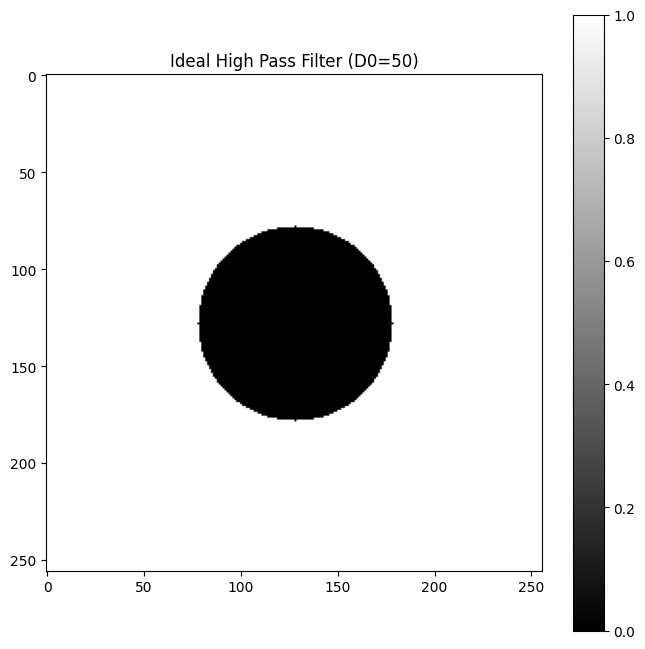

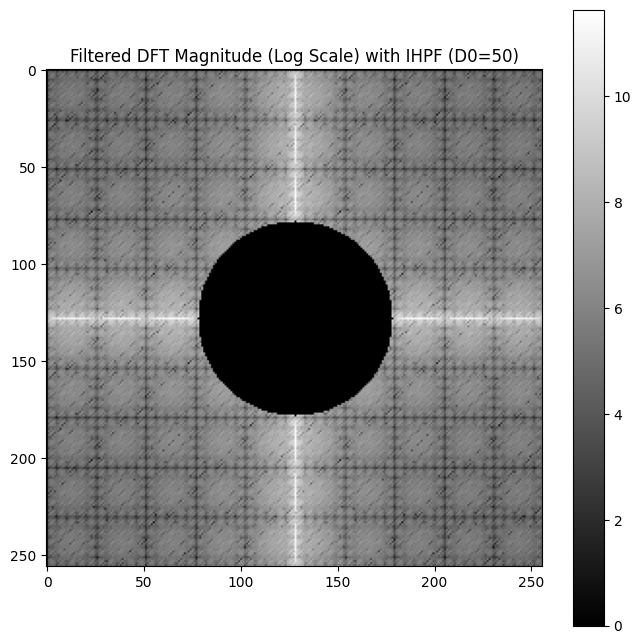

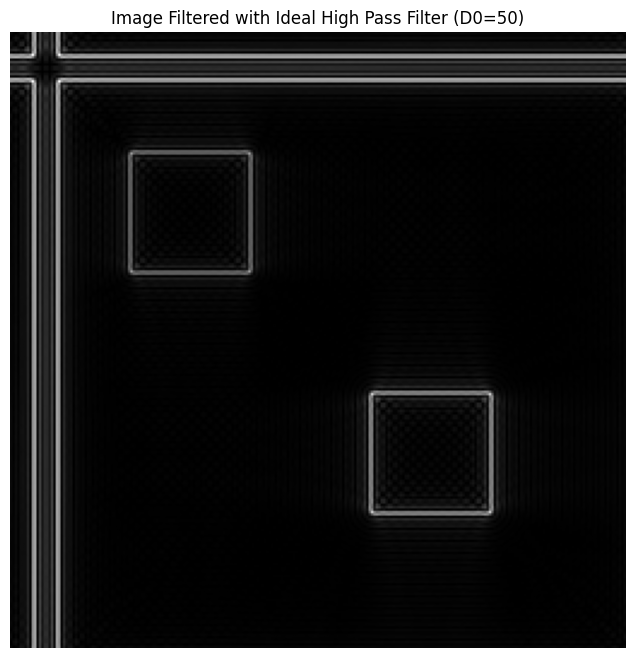

In [10]:
def ideal_high_pass_filter(shape, D0):
    P, Q = shape
    H_lp = ideal_low_pass_filter(shape, D0)
    H_hp = 1 - H_lp  # Ideal High Pass Filter = 1 - ILPF
    return H_hp

# Parameters
D0_hp = 50  # Cutoff frequency for high-pass filter

# Create the Ideal High Pass Filter (IHPF)
M, N = img_gray.shape
ihpf = ideal_high_pass_filter((M, N), D0_hp)

# Visualize the IHPF
plt.figure(figsize=(8, 8))
plt.imshow(ihpf, cmap='gray')
plt.title(f'Ideal High Pass Filter (D0={D0_hp})')
plt.colorbar()
plt.show()

# Apply the filter in the frequency domain
# F_img is the unshifted DFT of img_gray from Exercise 2.2
# We need to shift the filter to match the F_img (unshifted DFT)
ihpf_unshifted = np.fft.ifftshift(ihpf)
filtered_F_img_hp = F_img * ihpf_unshifted

# Visualize the filtered magnitude spectrum (shifted for better visualization)
filtered_F_shifted_hp = np.fft.fftshift(filtered_F_img_hp)
filtered_magnitude_spectrum_hp = np.log(1 + np.abs(filtered_F_shifted_hp))

plt.figure(figsize=(8, 8))
plt.imshow(filtered_magnitude_spectrum_hp, cmap='gray')
plt.title(f'Filtered DFT Magnitude (Log Scale) with IHPF (D0={D0_hp})')
plt.colorbar()
plt.show()

# Perform inverse DFT to get the filtered image
filtered_image_hp = np.abs(np.fft.ifft2(filtered_F_img_hp))

# Normalize the image for display
filtered_image_hp = cv2.normalize(filtered_image_hp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

plt.figure(figsize=(8, 8))
plt.imshow(filtered_image_hp, cmap='gray')
plt.title(f'Image Filtered with Ideal High Pass Filter (D0={D0_hp})')
plt.axis('off')
plt.show()


**Exercise 3.3 (10 points)** Notch filter
- Load image "car.png" and apply DFT. Visualize the results of DFT.
- Find the locations of frequencies, which correspond to the periodic patterns in image "car.png" e.g. manually.
- Remove the periodic patterns by applying the notch filter. Please visualize the filtered magnitude and the final image after applying notch filter.

Note:
- For simplicity, one can use the following ideal notch filter to depress the frequency at $(u_0, v_0)$:

$H(u,v) = 1$, if $|(u,v)- (u_0, v_0)|\geq D_0$, else $H(u,v)=0$.

$(u_0, v_0)$ represents the location of frequencies, which have to be depressed. Values of $(u_0, v_0)$ can be found in the magnitude image after DFT manually.


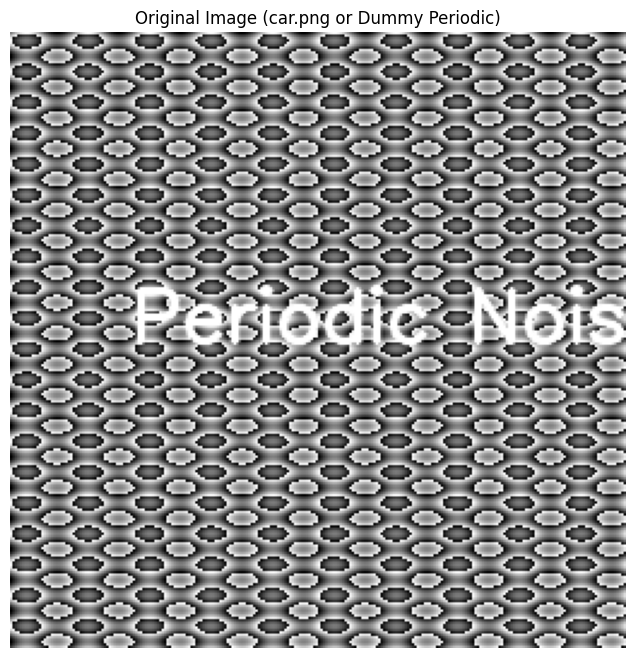

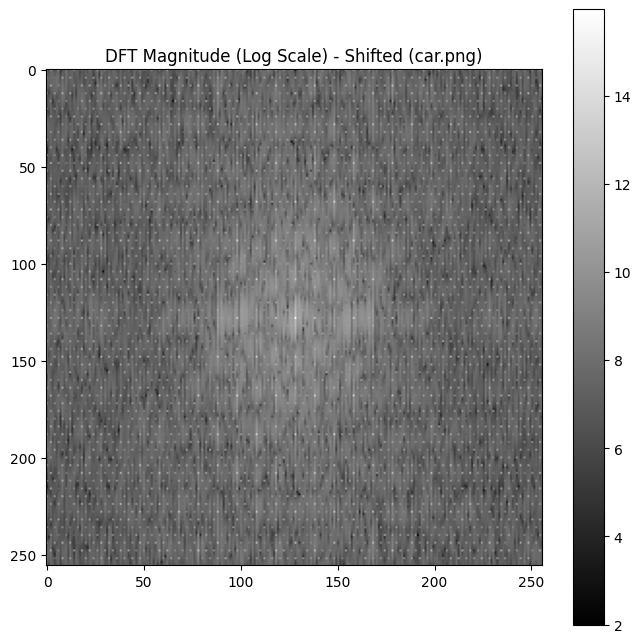

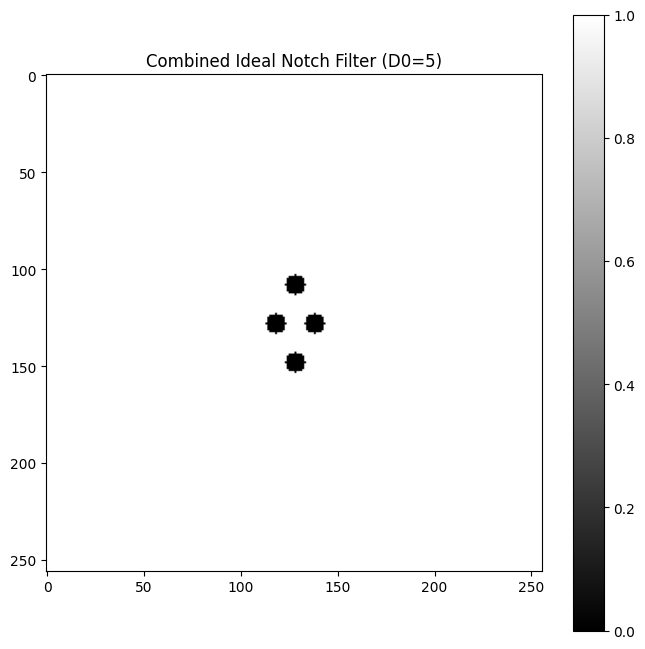

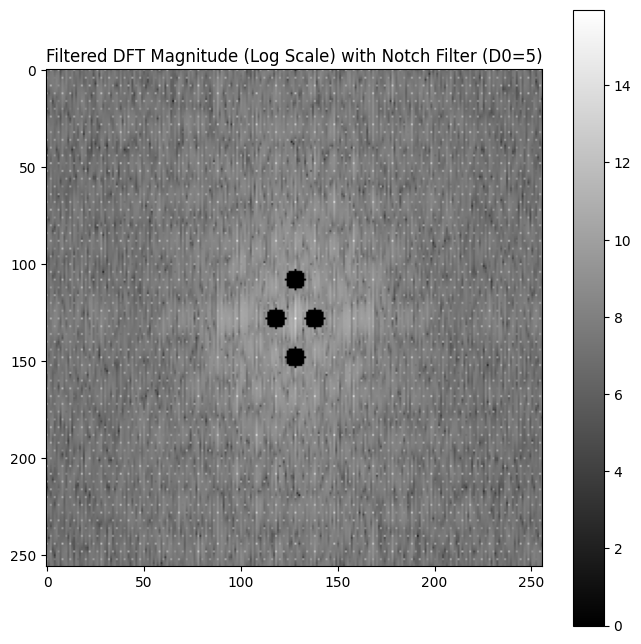

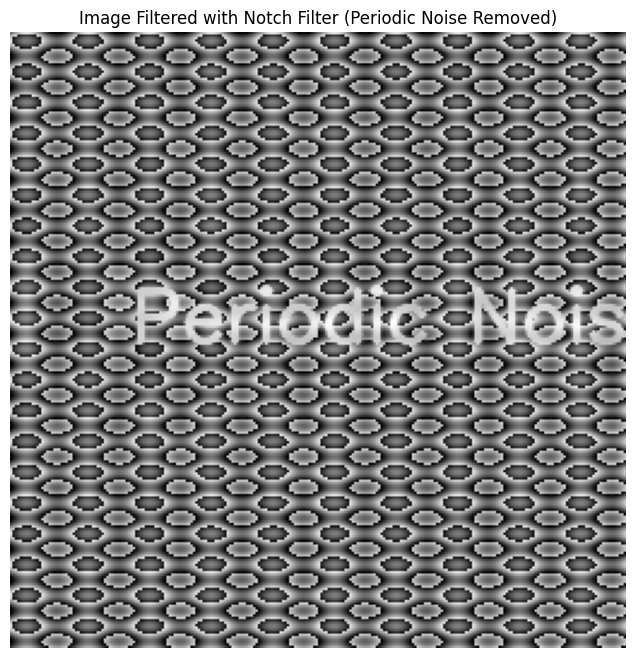

In [11]:
# Helper function to create a notch filter
def ideal_notch_filter(shape, center_uv, D0):
    P, Q = shape
    H = np.ones((P, Q), dtype=np.float32)
    u0, v0 = center_uv

    # Iterate through the frequency domain to set filter values
    for u in range(P):
        for v in range(Q):
            # Calculate distance from the center of the notch
            # Note: For notch filter, we are targeting specific points, not shifting the origin for distance calculation
            D_uv = np.sqrt((u - u0)**2 + (v - v0)**2)
            if D_uv <= D0:
                H[u, v] = 0  # Block frequencies within D0 of (u0, v0)
    return H

def create_two_notch_filters(shape, center_uv_1, center_uv_2, D0):
    """Creates a combined ideal notch filter for two symmetric points."""
    notch_filter_1 = ideal_notch_filter(shape, center_uv_1, D0)
    notch_filter_2 = ideal_notch_filter(shape, center_uv_2, D0)
    # Combine the two filters (if either blocks, then the combined filter blocks)
    # We need to consider that for periodic noise, we usually have symmetric pairs, so we define one filter
    # and then apply it and its symmetric counterpart.
    # A simple way to combine is to multiply them if they are both blocking (0)
    # or just use the first filter's logic if applied to F_shifted

    # More robust for actual use:
    H = np.ones(shape, dtype=np.float32)
    P, Q = shape
    u0_1, v0_1 = center_uv_1
    u0_2, v0_2 = center_uv_2

    for u in range(P):
        for v in range(Q):
            D_uv_1 = np.sqrt((u - u0_1)**2 + (v - v0_1)**2)
            D_uv_2 = np.sqrt((u - u0_2)**2 + (v - v0_2)**2)
            if D_uv_1 <= D0 or D_uv_2 <= D0:
                H[u, v] = 0
    return H


# Load image "car.png"
img_path_car = 'car.png'
try:
    img_car = cv2.imread(img_path_car, cv2.IMREAD_GRAYSCALE)
    if img_car is None:
        raise FileNotFoundError(f"Image '{img_path_car}' not found or could not be loaded.")
except FileNotFoundError:
    print(f"Warning: '{img_path_car}' not found. Creating a dummy image with periodic noise for demonstration.")
    # Create a dummy image with periodic patterns for demonstration
    M, N = 256, 256
    img_car = np.zeros((M, N), dtype=np.uint8)
    x = np.arange(N)
    y = np.arange(M)
    X, Y = np.meshgrid(x, y)
    # Add a horizontal sine wave (periodic noise)
    img_car = (127.5 * (np.sin(2 * np.pi * 10 * X / N) + np.sin(2 * np.pi * 20 * Y / M)) + 127.5).astype(np.uint8)
    # Add some text or a simple shape to make it more like a real image
    cv2.putText(img_car, 'Periodic Noise', (50, 128), cv2.FONT_HERSHEY_SIMPLEX, 1, 255, 2, cv2.LINE_AA)


plt.figure(figsize=(8, 8))
plt.imshow(img_car, cmap='gray')
plt.title('Original Image (car.png or Dummy Periodic)')
plt.axis('off')
plt.show()

# Apply DFT
F_car = np.fft.fft2(img_car)

# Shift zero frequency to center for visualization and filtering
F_shifted_car = np.fft.fftshift(F_car)
magnitude_spectrum_car = np.log(1 + np.abs(F_shifted_car))

plt.figure(figsize=(8, 8))
plt.imshow(magnitude_spectrum_car, cmap='gray')
plt.title('DFT Magnitude (Log Scale) - Shifted (car.png)')
plt.colorbar()
plt.show()

# --- Manually find the locations of frequencies --- (Based on visual inspection of the plot above)
# Assuming the dummy image, there will be bright spots (periodic noise) related to the sine waves.
# For the dummy image with sin(2 * pi * 10 * X / N) and sin(2 * pi * 20 * Y / M):
# The frequencies will be at (+-10, 0) and (0, +-20) approximately in the unshifted spectrum.
# In the *shifted* spectrum (center at P/2, Q/2):
# For the horizontal wave (10 cycles across N pixels), the frequency is at (10, 0) and (-10, 0)
# Relative to the center (M/2, N/2):
# (M/2, N/2 + 10) and (M/2, N/2 - 10) for horizontal pattern
# (M/2 + 20, N/2) and (M/2 - 20, N/2) for vertical pattern

M, N = img_car.shape
center_u, center_v = M // 2, N // 2

# Example values for the dummy image, these would be found visually for a real image
# These are the *shifted* coordinates to notch out

# For the horizontal sine wave (frequency 10 along x-axis)
notch_center_1_u = center_u
notch_center_1_v = center_v + 10
notch_center_sym_1_u = center_u
notch_center_sym_1_v = center_v - 10

# For the vertical sine wave (frequency 20 along y-axis)
notch_center_2_u = center_u + 20
notch_center_2_v = center_v
notch_center_sym_2_u = center_u - 20
notch_center_sym_2_v = center_v

# Also consider the DC component if needed to suppress, but usually it's around the center
# And very importantly, the fundamental frequency of the pattern will show up, and its harmonics too sometimes.
# Let's try to remove the two main frequency components for the dummy image.

D0_notch = 5  # Cutoff radius for the notch filter. Adjust based on how wide the frequency components are.

# Create the notch filter for the identified periodic components
notch_filter_H = create_two_notch_filters((M, N),
                                        (notch_center_1_u, notch_center_1_v), # Freq 1
                                        (notch_center_sym_1_u, notch_center_sym_1_v), # Freq 1 symmetric
                                        D0_notch)

notch_filter_V = create_two_notch_filters((M, N),
                                        (notch_center_2_u, notch_center_2_v), # Freq 2
                                        (notch_center_sym_2_u, notch_center_sym_2_v), # Freq 2 symmetric
                                        D0_notch)

# Combine the two notch filters
combined_notch_filter = notch_filter_H * notch_filter_V


plt.figure(figsize=(8, 8))
plt.imshow(combined_notch_filter, cmap='gray')
plt.title(f'Combined Ideal Notch Filter (D0={D0_notch})')
plt.colorbar()
plt.show()

# Apply the notch filter in the frequency domain (to the shifted DFT)
filtered_F_shifted_car = F_shifted_car * combined_notch_filter

# Visualize the filtered magnitude spectrum
filtered_magnitude_spectrum_notch = np.log(1 + np.abs(filtered_F_shifted_car))

plt.figure(figsize=(8, 8))
plt.imshow(filtered_magnitude_spectrum_notch, cmap='gray')
plt.title(f'Filtered DFT Magnitude (Log Scale) with Notch Filter (D0={D0_notch})')
plt.colorbar()
plt.show()

# Perform inverse DFT to get the filtered image
# First, inverse shift the filtered DFT back
F_filtered_unshifted_car = np.fft.ifftshift(filtered_F_shifted_car)
inv_img_notch = np.fft.ifft2(F_filtered_unshifted_car)

# Take the real part and normalize for display
reconstructed_img_notch = np.abs(inv_img_notch)
reconstructed_img_notch = cv2.normalize(reconstructed_img_notch, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

plt.figure(figsize=(8, 8))
plt.imshow(reconstructed_img_notch, cmap='gray')
plt.title('Image Filtered with Notch Filter (Periodic Noise Removed)')
plt.axis('off')
plt.show()
